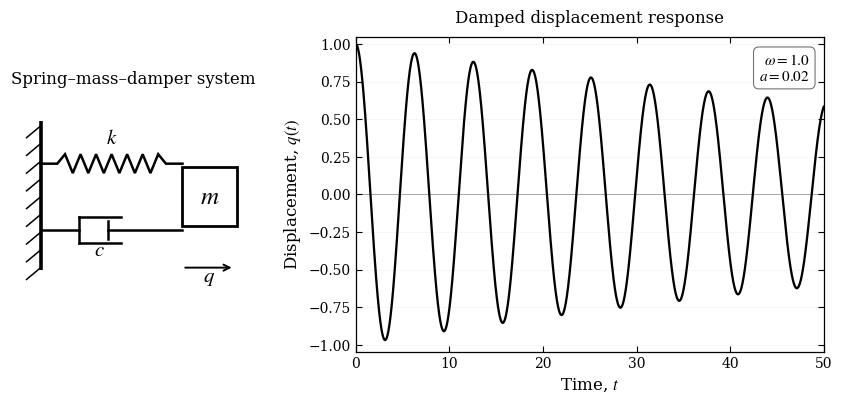

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.patches import Rectangle

# ============================================================
# PUBLICATION SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.9,
})


# ============================================================
# DAMPED HARMONIC OSCILLATOR
#
#       q'' + a q' + omega^2 q = 0
#
# Natural frequency:     omega = 1.0
# Damping coefficient:   a     = 0.02
# ============================================================

omega = 1.0
a = 0.02

q0 = 1.0
v0 = 0.0

t = np.linspace(0, 50, 3000)


def oscillator(t, y):
    q, q_dot = y

    q_ddot = -a * q_dot - omega**2 * q

    return [q_dot, q_ddot]


sol = solve_ivp(
    oscillator,
    (t[0], t[-1]),
    (q0, v0),
    t_eval=t,
    rtol=1e-11,
    atol=1e-13
)

q = sol.y[0]


# ============================================================
# FIGURE
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10.5, 4.1),
    gridspec_kw={
        "width_ratios": [1.05, 2.0],
        "wspace": 0.28
    }
)


# ============================================================
# LEFT: SPRING-MASS-DAMPER
# ============================================================

ax1.set_xlim(0, 5.2)
ax1.set_ylim(0.5, 4.7)
ax1.set_aspect("equal")
ax1.axis("off")

lw = 1.8


# ------------------------------------------------------------
# Fixed wall
# ------------------------------------------------------------

wall_x = 0.65

ax1.plot(
    [wall_x, wall_x],
    [1.0, 4.15],
    color="black",
    lw=2.6,
    solid_capstyle="butt"
)

# Wall hatch
for y in np.linspace(1.05, 4.05, 9):
    ax1.plot(
        [wall_x - 0.30, wall_x],
        [y - 0.25, y],
        color="black",
        lw=1.1
    )


# ============================================================
# MASS
# ============================================================

mass_x = 3.65
mass_y = 2.55
mass_w = 1.15
mass_h = 1.25

mass = Rectangle(
    (mass_x, mass_y - mass_h/2),
    mass_w,
    mass_h,
    facecolor="white",
    edgecolor="black",
    linewidth=2.0
)

ax1.add_patch(mass)

ax1.text(
    mass_x + mass_w/2,
    mass_y,
    r"$m$",
    ha="center",
    va="center",
    fontsize=18
)


# ============================================================
# SPRING
# ============================================================

y_spring = 3.25

spring_start = wall_x
spring_end = mass_x

straight = 0.35
n_coils = 7
amplitude = 0.20

# First straight segment
x_spring = [spring_start, spring_start + straight]
y_values = [y_spring, y_spring]

# Zig-zag spring
coil_start = spring_start + straight
coil_end = spring_end - straight

coil_x = np.linspace(
    coil_start,
    coil_end,
    2 * n_coils + 1
)

coil_y = np.full_like(coil_x, y_spring)

for i in range(1, len(coil_x) - 1):
    coil_y[i] += amplitude if i % 2 else -amplitude

x_spring.extend(coil_x)
y_values.extend(coil_y)

# Final straight segment
x_spring.extend([spring_end - straight, spring_end])
y_values.extend([y_spring, y_spring])

ax1.plot(
    x_spring,
    y_values,
    color="black",
    lw=lw,
    solid_joinstyle="miter"
)

ax1.text(
    2.15,
    3.68,
    r"$k$",
    ha="center",
    fontsize=15
)


# ============================================================
# DAMPER
# ============================================================

y_damp = 1.85

# Wall -> damper
ax1.plot(
    [wall_x, 1.45],
    [y_damp, y_damp],
    color="black",
    lw=lw
)

# Damper casing
ax1.plot(
    [1.45, 1.45],
    [y_damp - 0.27, y_damp + 0.27],
    color="black",
    lw=lw
)

ax1.plot(
    [1.45, 2.35],
    [y_damp + 0.27, y_damp + 0.27],
    color="black",
    lw=lw
)

ax1.plot(
    [1.45, 2.35],
    [y_damp - 0.27, y_damp - 0.27],
    color="black",
    lw=lw
)

# Piston plate
ax1.plot(
    [2.08, 2.08],
    [y_damp - 0.19, y_damp + 0.19],
    color="black",
    lw=lw
)

# Piston rod -> mass
ax1.plot(
    [2.08, mass_x],
    [y_damp, y_damp],
    color="black",
    lw=lw
)

ax1.text(
    1.90,
    1.30,
    r"$c$",
    ha="center",
    fontsize=15
)


# ============================================================
# DISPLACEMENT ARROW
# ============================================================

arrow_y = 1.05

ax1.annotate(
    "",
    xy=(4.75, arrow_y),
    xytext=(3.65, arrow_y),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.4
    )
)

ax1.text(
    4.22,
    0.76,
    r"$q$",
    ha="center",
    fontsize=15
)

ax1.set_title(
    "Spring–mass–damper system",
    pad=8
)


# ============================================================
# RIGHT: DAMPED RESPONSE
# ============================================================

ax2.plot(
    t,
    q,
    color="black",
    lw=1.65
)

# Zero reference
ax2.axhline(
    0,
    color="0.65",
    lw=0.7,
    zorder=0
)

ax2.set_xlabel(r"Time, $t$")
ax2.set_ylabel(r"Displacement, $q(t)$")

ax2.set_title(
    "Damped displacement response",
    pad=10
)

ax2.set_xlim(0, 50)
ax2.set_ylim(-1.05, 1.05)

ax2.set_xticks(
    np.arange(0, 51, 10)
)

ax2.tick_params(
    direction="in",
    top=True,
    right=True,
    length=4,
    width=0.8
)

ax2.grid(
    axis="y",
    linewidth=0.45,
    alpha=0.18
)

for spine in ax2.spines.values():
    spine.set_linewidth(0.9)


# ============================================================
# PARAMETER BOX
# ============================================================

parameter_text = (
    r"$\omega = 1.0$" "\n"
    r"$a = 0.02$"
)

ax2.text(
    0.97,
    0.95,
    parameter_text,
    transform=ax2.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="0.45",
        linewidth=0.8
    )
)


# ============================================================
# EXPORT
# ============================================================

fig.align_labels()

plt.savefig(
    "SHO_diagram.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.04
)

plt.savefig(
    "SHO_diagram.png",
    format="png",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0.04
)

plt.show()

In [ ]:
# ============================================================
# HIGH-QUALITY EXPORT + DOWNLOAD IN GOOGLE COLAB
# ============================================================

from google.colab import files

# 1. Vector PDF — BEST for LaTeX / journal paper
fig.savefig(
    "SHO_diagram.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05
)

# 2. High-resolution PNG — 1200 DPI
fig.savefig(
    "SHO_diagram_HQ.png",
    format="png",
    dpi=1200,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

plt.show()

# Download high-resolution PNG
files.download("SHO_diagram.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>